In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

Mounted at /content/drive


In [3]:
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeRegressor

def mini_boosting(eta, n_arbres=200, profondeur=3):
    pred_train = np.full(len(y_train), y_train.mean())   # étape 0 : la moyenne
    pred_val = np.full(len(y_val), y_train.mean())
    historique = []
    for i in range(n_arbres):
        erreurs = y_train - pred_train                     # ce qu'il reste à corriger
        arbre = DecisionTreeRegressor(max_depth=profondeur, random_state=i)
        arbre.fit(X_train, erreurs)                        # l'arbre apprend les erreurs
        pred_train += eta * arbre.predict(X_train)         # on ajoute une fraction
        pred_val += eta * arbre.predict(X_val)
        historique.append({
            "arbres": i + 1,
            "erreur_train": np.abs(y_train - pred_train).mean(),
            "f1_macro_val": f1_score(y_val, (pred_val >= 0.5).astype(int), average="macro"),
        })
    return pd.DataFrame(historique)

h_petit = mini_boosting(eta=0.1)
h_grand = mini_boosting(eta=1.0)
h_petit.iloc[[0, 4, 19, 49, 99, 199]].round(3)

,arbres,erreur_train,f1_macro_val
0,1,0.393,0.412
4,5,0.318,0.726
19,20,0.191,0.837
49,50,0.148,0.848
99,100,0.136,0.850
199,200,0.118,0.845


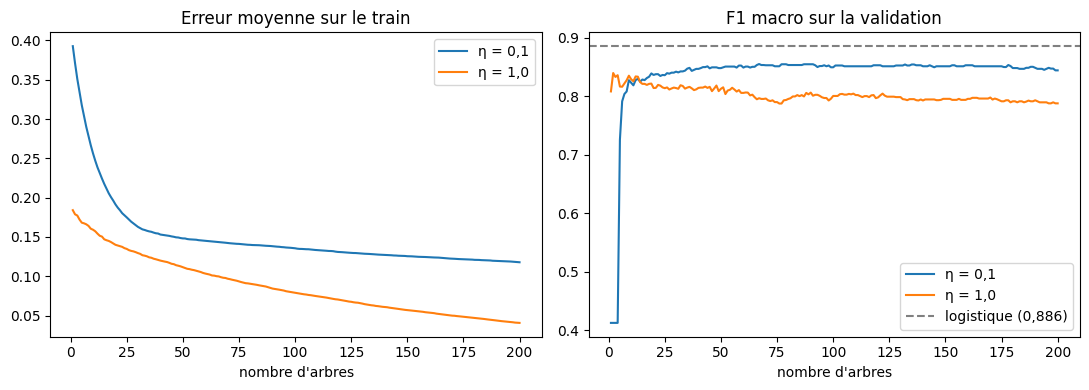

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for h, nom in [(h_petit, "η = 0,1"), (h_grand, "η = 1,0")]:
    axes[0].plot(h["arbres"], h["erreur_train"], label=nom)
    axes[1].plot(h["arbres"], h["f1_macro_val"], label=nom)
axes[0].set_title("Erreur moyenne sur le train")
axes[1].set_title("F1 macro sur la validation")
axes[1].axhline(0.886, color="gray", linestyle="--", label="logistique (0,886)")
for ax in axes:
    ax.set_xlabel("nombre d'arbres")
    ax.legend()
plt.tight_layout()
plt.show()

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from aeroguard.evaluation import metriques

hgb = HistGradientBoostingClassifier(learning_rate=0.1, max_iter=300, random_state=42)
hgb.fit(X_train, y_train)
s = metriques(y_val, hgb.predict(X_val), hgb.predict_proba(X_val)[:, 1])
print({k: round(v, 3) for k, v in s.items()})

{'precision': 0.879, 'rappel': 0.962, 'f1': 0.919, 'f1_macro': 0.846, 'vn': 168, 'fp': 76, 'fn': 22, 'vp': 553, 'pr_auc': 0.984}
